# Why Refractive Calibration Matters

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tlancaster6/AquaCal/blob/main/docs/tutorials/02_synthetic_validation.ipynb)

Underwater imaging systems view targets through a flat air-water interface. A standard
pinhole camera model ignores refraction at this interface, treating light as travelling
in a straight line from camera to target. AquaCal corrects this using Snell's law.

**But does it actually matter?** This tutorial answers that question with three
controlled synthetic experiments:

1. **Parameter Fidelity** — Can both models fit the data? Which one recovers correct parameters?
2. **Depth Generalization** — Using the same calibration, how does 3D reconstruction accuracy vary with depth?
3. **XY vs Z Anisotropy** — How does reconstruction precision differ between lateral (XY) and depth (Z) directions?

Because we control all ground truth parameters, we can measure exactly where each
model fails and why.

In [1]:
# Colab setup — clones the repo and installs AquaCal if running on Google Colab.
# This notebook imports test helpers from the repo's tests/ directory, so a full
# clone is needed (not just pip install). When running locally, this cell is a no-op.
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("/content/AquaCal/src"):
        print("Colab detected — cloning repo and installing AquaCal...")
        !git clone --depth 1 https://github.com/tlancaster6/AquaCal.git /content/AquaCal
        !pip install -q -e /content/AquaCal
    else:
        print("AquaCal repo already present.")
    os.chdir("/content/AquaCal")
    print("Done.")
else:
    print("Local environment — skipping install.")

Local environment — skipping install.


In [2]:
# Toggle rig size:
#   "small" — 4 cameras, 20 frames, ideal conditions. Fast, ~2 min total.
#   "large" — 12 cameras, 30 frames, realistic noise. Compelling results, ~60 min total.
RIG_SIZE = "large"

OUTPUT_DIR = Path("output")  # exported data artifacts

## Setup and Imports

In [3]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make sure project root is on path (needed when running as a notebook)
_project_root = Path().resolve()
while _project_root.name and not (_project_root / "src").exists():
    _project_root = _project_root.parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from aquacal.config.schema import BoardConfig, InterfaceParams
from aquacal.core.board import BoardGeometry
from aquacal.validation.reconstruction import triangulate_charuco_corners
from aquacal.validation.reprojection import compute_reprojection_errors
from tests.synthetic.experiment_helpers import (
    calibrate_synthetic,
    compute_per_camera_errors,
    evaluate_reconstruction,
)
from tests.synthetic.ground_truth import (
    SyntheticScenario,
    create_scenario,
    generate_dense_xy_grid,
    generate_real_rig_array,
    generate_real_rig_trajectory,
    generate_synthetic_detections,
)

# Consistent color palette for all plots
COLOR_REFRACTIVE = "#2196F3"      # Blue
COLOR_NON_REFRACTIVE = "#F44336"  # Red
LABEL_REFRACTIVE = "Refractive (AquaCal)"
LABEL_NON_REFRACTIVE = "Non-refractive (pinhole)"

print("Imports complete.")

Imports complete.


## Preset Configuration

The `"small"` preset uses the `"ideal"` scenario: 4 cameras arranged in a grid,
at the real-rig standoff (~1.03 m above water), boards at ~1.18–2.0 m depth,
no noise. This is fast and lets you verify the math.

The `"large"` preset uses the `"realistic"` scenario: 12 cameras with positions
matching the real AquaCal hardware rig (idealized: common intrinsics, optical axes
aligned to Z), water surface at ~1.03 m, boards at 1.1–2.0 m depth, 0.5 px noise.
This produces compelling quantitative results.

In [4]:
if RIG_SIZE == "small":
    # create_scenario("ideal"): 4 cameras at Z=0, water at the real-rig standoff
    # (~1.031 m, D-19.3-09), boards derived to a legal depth_range floor of
    # ~1.176 m (D-19.3-01/GEOM-01). All test/sweep depths must be >= that floor.
    SCENARIO_NAME = "ideal"
    TEST_DEPTHS = [1.20, 1.30, 1.40, 1.50, 1.65]
    N_GRID = 4  # smaller grid for 4-camera rig
    XY_EXTENT = 0.05
    XY_CENTER = (0.0, 0.0)
    TILT_DEG = 2.0
else:
    # create_scenario("realistic"): 12 cameras, water at ~1.03m, boards at 1.1-2.0m depth
    SCENARIO_NAME = "realistic"
    TEST_DEPTHS = [1.10, 1.20, 1.30, 1.40, 1.50, 1.70, 2.00, 2.50]
    N_GRID = 7
    XY_EXTENT = 0.5
    XY_CENTER = (-0.34, 0.55)  # centroid of the 12-camera array
    TILT_DEG = 3.0

print(f"RIG_SIZE = {RIG_SIZE!r}")
print(f"  Scenario:    {SCENARIO_NAME}")
print(f"  Test depths: {TEST_DEPTHS}")

RIG_SIZE = 'large'
  Scenario:    realistic
  Test depths: [1.1, 1.2, 1.3, 1.4, 1.5, 1.7, 2.0, 2.5]


## Experiment 1: Parameter Fidelity

**Question:** When we calibrate both models on identical data, do they recover
the correct camera parameters?

We generate a synthetic scenario with known ground truth, then run the full
calibration pipeline twice — once with the refractive model (n_water = 1.333)
and once with the non-refractive pinhole approximation (n_water = 1.0). Both
optimizations minimize reprojection error on the same 2D observations.

The key insight: **a model can fit 2D observations without learning correct 3D geometry**.
If the model is wrong, it will compensate by adjusting focal length and camera positions.

In [5]:
print("=== Experiment 1: Parameter Fidelity ===")
scenario = create_scenario(SCENARIO_NAME, seed=42)
print(f"Scenario: {scenario.description}")
print(f"  Cameras: {len(scenario.intrinsics)}")
print(f"  Frames:  {len(scenario.board_poses)}")
print(f"  Noise:   {scenario.noise_std} px")

print("\nCalibrating refractive model (n_water=1.333)...")
result_refr, _ = calibrate_synthetic(scenario, n_water=1.333, refine_intrinsics=True)
errors_refr = compute_per_camera_errors(result_refr, scenario)
print(f"  Reprojection RMS: {result_refr.diagnostics.reprojection_error_rms:.4f} px")

print("\nCalibrating non-refractive model (n_water=1.0)...")
result_nonrefr, _ = calibrate_synthetic(scenario, n_water=1.0, refine_intrinsics=True)
errors_nonrefr = compute_per_camera_errors(result_nonrefr, scenario)
print(f"  Reprojection RMS: {result_nonrefr.diagnostics.reprojection_error_rms:.4f} px")

print("\nBoth calibrations complete.")
print(f"  Note: similar reprojection errors ({result_refr.diagnostics.reprojection_error_rms:.3f} vs "
      f"{result_nonrefr.diagnostics.reprojection_error_rms:.3f} px) — "
      "look at parameter errors next.")

# Interface distance (water_z) recovery — refractive model only
gt_wz = np.mean(list(scenario.water_zs.values()))
est_wz = np.mean([c.water_z for c in result_refr.cameras.values()])
wz_err_mm = (est_wz - gt_wz) * 1000
wz_err_pct = (est_wz - gt_wz) / gt_wz * 100
print(f"\nInterface distance (water_z) recovery [refractive model only]:")
print(f"  Ground truth: {gt_wz * 1000:.1f} mm")
print(f"  Estimated:    {est_wz * 1000:.1f} mm")
print(f"  Error:        {wz_err_mm:+.2f} mm ({wz_err_pct:+.3f}%)")

# Calibration depth range (for Experiment 2 plots)
_board_zs = [bp.tvec[2] for bp in scenario.board_poses]
CALIB_DEPTH_RANGE = (min(_board_zs), max(_board_zs))
print(f"\nCalibration depth range: ({CALIB_DEPTH_RANGE[0]:.2f}, {CALIB_DEPTH_RANGE[1]:.2f}) m")

=== Experiment 1: Parameter Fidelity ===
Scenario: 12-camera rig matching real hardware (idealized geometry)
  Cameras: 12
  Frames:  30
  Noise:   0.5 px

Calibrating refractive model (n_water=1.333)...
Stage 2: Extrinsic initialization...
Stage 3: Joint refractive optimization...
`ftol` termination condition is satisfied.
Function evaluations 17, initial cost 3.3111e+04, final cost 3.4102e+03, first-order optimality 2.31e-03.
Stage 4: Intrinsic refinement...
`ftol` termination condition is satisfied.
Function evaluations 21, initial cost 3.4102e+03, final cost 3.4054e+03, first-order optimality 1.50e+01.
  Reprojection RMS: 0.4984 px

Calibrating non-refractive model (n_water=1.0)...
Stage 2: Extrinsic initialization...
Stage 3: Joint refractive optimization...
`xtol` termination condition is satisfied.
Function evaluations 42, initial cost 1.2535e+05, final cost 2.7124e+04, first-order optimality 4.26e-03.
Stage 4: Intrinsic refinement...
`xtol` termination condition is satisfied.
F

### Focal Length Recovery

When refraction bends rays at the interface, a non-refractive model compensates by
adjusting focal length. The result: a systematically biased focal length that happens
to minimize 2D reprojection error but does not match the true optics.

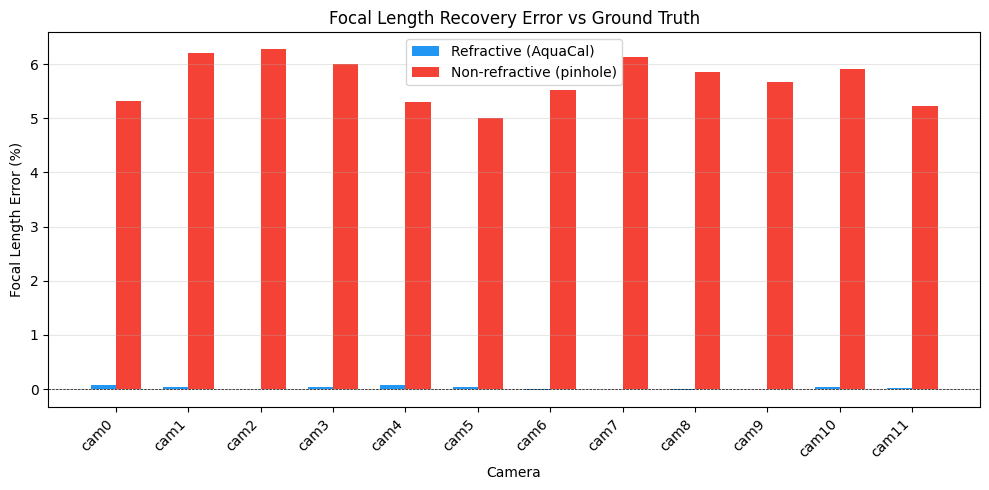

Mean absolute focal length error:
  Refractive:     0.033%
  Non-refractive: 5.699%


In [6]:
camera_names = sorted(scenario.intrinsics.keys(), key=lambda s: int(s.replace("cam", "")))
x = np.arange(len(camera_names))
width = 0.35

focal_refr = [errors_refr[cam]["focal_length_error_pct"] for cam in camera_names]
focal_nonrefr = [errors_nonrefr[cam]["focal_length_error_pct"] for cam in camera_names]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, focal_refr, width, label=LABEL_REFRACTIVE, color=COLOR_REFRACTIVE)
ax.bar(x + width / 2, focal_nonrefr, width, label=LABEL_NON_REFRACTIVE, color=COLOR_NON_REFRACTIVE)
ax.set_xlabel("Camera")
ax.set_ylabel("Focal Length Error (%)")
ax.set_title("Focal Length Recovery Error vs Ground Truth")
ax.set_xticks(x)
ax.set_xticklabels(camera_names, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

mean_focal_refr = np.mean([abs(e) for e in focal_refr])
mean_focal_nonrefr = np.mean([abs(e) for e in focal_nonrefr])
print(f"Mean absolute focal length error:")
print(f"  Refractive:     {mean_focal_refr:.3f}%")
print(f"  Non-refractive: {mean_focal_nonrefr:.3f}%")

### Camera Z Position Recovery

Along with focal length, the non-refractive model misplaces camera positions along
the Z axis (depth). These two biases together produce a model that fits 2D projections
but triangulates 3D positions incorrectly.

Because the reference camera (cam0) is fixed at the world-frame origin during
optimization, its raw Z error is always zero by construction. To reveal the
systematic shift the model would have applied to the entire rig, we subtract
the mean Z error of the free cameras from all cameras (mean-shift correction).

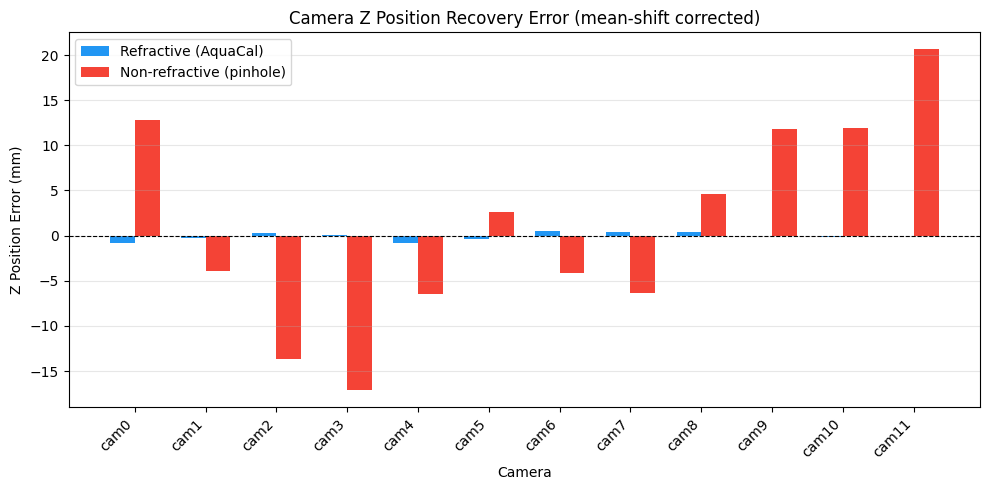

Mean absolute Z position error (mean-shift corrected):
  Refractive:     0.35 mm
  Non-refractive: 9.66 mm


In [7]:
z_refr_raw = [errors_refr[cam]["z_position_error_mm"] for cam in camera_names]
z_nonrefr_raw = [errors_nonrefr[cam]["z_position_error_mm"] for cam in camera_names]

# The reference camera (cam0) is pinned at ground truth during optimization,
# so its raw error is always 0. To reveal the systematic Z shift the model
# would have applied to cam0, subtract the mean error of the free cameras
# from all cameras. This gives each camera's estimated distance from its
# true position, including the reference.
ref_cam = camera_names[0]
free_cams = camera_names[1:]

mean_z_refr = np.mean([errors_refr[cam]["z_position_error_mm"] for cam in free_cams])
mean_z_nonrefr = np.mean([errors_nonrefr[cam]["z_position_error_mm"] for cam in free_cams])

z_refr = [v - mean_z_refr for v in z_refr_raw]
z_nonrefr = [v - mean_z_nonrefr for v in z_nonrefr_raw]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, z_refr, width, label=LABEL_REFRACTIVE, color=COLOR_REFRACTIVE)
ax.bar(x + width / 2, z_nonrefr, width, label=LABEL_NON_REFRACTIVE, color=COLOR_NON_REFRACTIVE)
ax.set_xlabel("Camera")
ax.set_ylabel("Z Position Error (mm)")
ax.set_title("Camera Z Position Recovery Error (mean-shift corrected)")
ax.set_xticks(x)
ax.set_xticklabels(camera_names, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

mean_z_refr_abs = np.mean([abs(e) for e in z_refr])
mean_z_nonrefr_abs = np.mean([abs(e) for e in z_nonrefr])
print(f"Mean absolute Z position error (mean-shift corrected):")
print(f"  Refractive:     {mean_z_refr_abs:.2f} mm")
print(f"  Non-refractive: {mean_z_nonrefr_abs:.2f} mm")

### Camera XY Position Recovery

Top-down view of camera positions. Arrows show how far each estimated position
is from ground truth. A good calibration produces very short arrows.

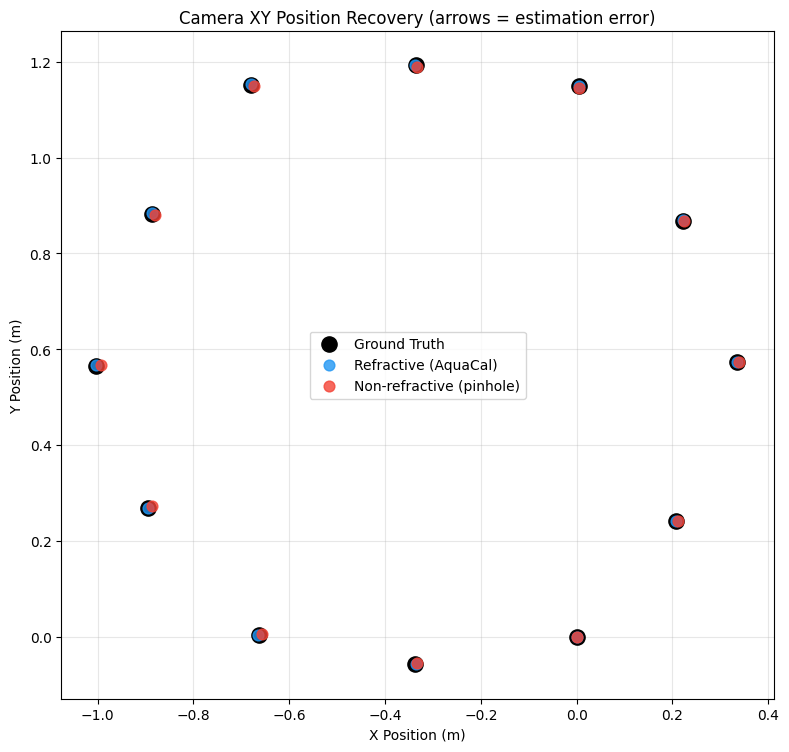

Mean XY position error:
  Refractive:     0.47 mm
  Non-refractive: 4.94 mm


In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

for i, cam_name in enumerate(camera_names):
    C_gt = scenario.extrinsics[cam_name].C
    C_refr = result_refr.cameras[cam_name].extrinsics.C
    C_nonrefr = result_nonrefr.cameras[cam_name].extrinsics.C

    gt_label = "Ground Truth" if i == 0 else None
    refr_label = LABEL_REFRACTIVE if i == 0 else None
    nonrefr_label = LABEL_NON_REFRACTIVE if i == 0 else None

    ax.scatter(C_gt[0], C_gt[1], color="black", s=120, zorder=3, label=gt_label, marker="o")
    ax.scatter(C_refr[0], C_refr[1], color=COLOR_REFRACTIVE, s=60, zorder=4, label=refr_label, alpha=0.8)
    ax.scatter(C_nonrefr[0], C_nonrefr[1], color=COLOR_NON_REFRACTIVE, s=60, zorder=4, label=nonrefr_label, alpha=0.8)

    dx_refr = C_refr[0] - C_gt[0]
    dy_refr = C_refr[1] - C_gt[1]
    dx_nonrefr = C_nonrefr[0] - C_gt[0]
    dy_nonrefr = C_nonrefr[1] - C_gt[1]

    arrow_kw = dict(head_width=0.015, head_length=0.008, length_includes_head=True)
    ax.arrow(C_gt[0], C_gt[1], dx_refr, dy_refr, color=COLOR_REFRACTIVE, alpha=0.6, **arrow_kw)
    ax.arrow(C_gt[0], C_gt[1], dx_nonrefr, dy_nonrefr, color=COLOR_NON_REFRACTIVE, alpha=0.6, **arrow_kw)

ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Camera XY Position Recovery (arrows = estimation error)")
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

mean_xy_refr = np.mean([errors_refr[cam]["xy_position_error_mm"] for cam in camera_names])
mean_xy_nonrefr = np.mean([errors_nonrefr[cam]["xy_position_error_mm"] for cam in camera_names])
print(f"Mean XY position error:")
print(f"  Refractive:     {mean_xy_refr:.2f} mm")
print(f"  Non-refractive: {mean_xy_nonrefr:.2f} mm")

### Experiment 1 Takeaway

Both models achieve similar reprojection error — the 2D fitting quality looks the same.
But the non-refractive model absorbs the refraction effect into systematically biased
focal lengths and camera positions. The refractive model recovers the true physical
parameters.

**Why it matters:** Biased parameters produce systematic 3D reconstruction errors
that grow with depth — exactly what Experiment 2 will show.

## Experiment 2: Depth Generalization

**Question:** How does 3D reconstruction accuracy vary with depth for each model?

Real underwater surveys rarely stay at exactly the calibration depth. Fish tracking
systems follow animals at varying depths; coral surveys cover different depth strata.

Using the same calibrations from Experiment 1, we evaluate 3D reconstruction accuracy
at a range of individual test depths. The refractive model should perform consistently
because it learned the correct geometry; the non-refractive model's biased parameters
produce depth-dependent errors.

In [9]:
print("=== Experiment 2: Depth Generalization ===")
print(f"Using calibrations from Experiment 1")
print(f"  Refractive RMS:     {result_refr.diagnostics.reprojection_error_rms:.4f} px")
print(f"  Non-refractive RMS: {result_nonrefr.diagnostics.reprojection_error_rms:.4f} px")
print(f"Test depths: {TEST_DEPTHS}")

board_exp2 = BoardGeometry(scenario.board_config)
print("\nEvaluating at test depths...")

=== Experiment 2: Depth Generalization ===
Using calibrations from Experiment 1
  Refractive RMS:     0.4984 px
  Non-refractive RMS: 1.3764 px
Test depths: [1.1, 1.2, 1.3, 1.4, 1.5, 1.7, 2.0, 2.5]

Evaluating at test depths...


In [10]:
results_refr_exp2 = []
results_nonrefr_exp2 = []
# Save intermediates for Experiment 3 (XY vs Z anisotropy)
exp2_test_poses = []
exp2_test_detections = []

for depth in TEST_DEPTHS:
    print(f"  Evaluating Z = {depth:.2f} m...")

    test_poses = generate_dense_xy_grid(
        depth=depth,
        n_grid=N_GRID,
        xy_extent=XY_EXTENT,
        xy_center=XY_CENTER,
        tilt_deg=TILT_DEG,
        frame_offset=1000,
        seed=42 + int(depth * 100),
    )

    test_detections = generate_synthetic_detections(
        intrinsics=scenario.intrinsics,
        extrinsics=scenario.extrinsics,
        water_zs=scenario.water_zs,
        board=board_exp2,
        board_poses=test_poses,
        noise_std=scenario.noise_std,
        seed=42 + int(depth * 100),
    )

    exp2_test_poses.append(test_poses)
    exp2_test_detections.append(test_detections)

    err_refr = evaluate_reconstruction(result_refr, board_exp2, test_detections)
    err_nonrefr = evaluate_reconstruction(result_nonrefr, board_exp2, test_detections)

    # Reprojection error at this test depth using GT board poses
    test_poses_dict = {bp.frame_idx: bp for bp in test_poses}
    reproj_refr = compute_reprojection_errors(result_refr, test_detections, test_poses_dict)
    reproj_nonrefr = compute_reprojection_errors(result_nonrefr, test_detections, test_poses_dict)

    true_dist = scenario.board_config.square_size
    scale_refr = 1.0 + (err_refr.signed_mean / true_dist)
    scale_nonrefr = 1.0 + (err_nonrefr.signed_mean / true_dist)

    results_refr_exp2.append({
        "depth": depth,
        "signed_mean_mm": err_refr.signed_mean * 1000,
        "rmse_mm": err_refr.rmse * 1000,
        "scale": scale_refr,
        "reproj_rms_px": reproj_refr.rms,
        "spatial": err_refr.spatial,
    })
    results_nonrefr_exp2.append({
        "depth": depth,
        "signed_mean_mm": err_nonrefr.signed_mean * 1000,
        "rmse_mm": err_nonrefr.rmse * 1000,
        "scale": scale_nonrefr,
        "reproj_rms_px": reproj_nonrefr.rms,
        "spatial": err_nonrefr.spatial,
    })

print("Depth sweep complete.")

  Evaluating Z = 1.10 m...
  Evaluating Z = 1.20 m...
  Evaluating Z = 1.30 m...
  Evaluating Z = 1.40 m...
  Evaluating Z = 1.50 m...
  Evaluating Z = 1.70 m...
  Evaluating Z = 2.00 m...
  Evaluating Z = 2.50 m...
Depth sweep complete.


### Signed Error vs Depth

The shaded region marks the calibration depth range. The refractive model maintains
low, uniform error at all depths. The non-refractive model shows systematic
depth-dependent bias because its wrong geometry produces scale errors that grow
with distance from the water surface.

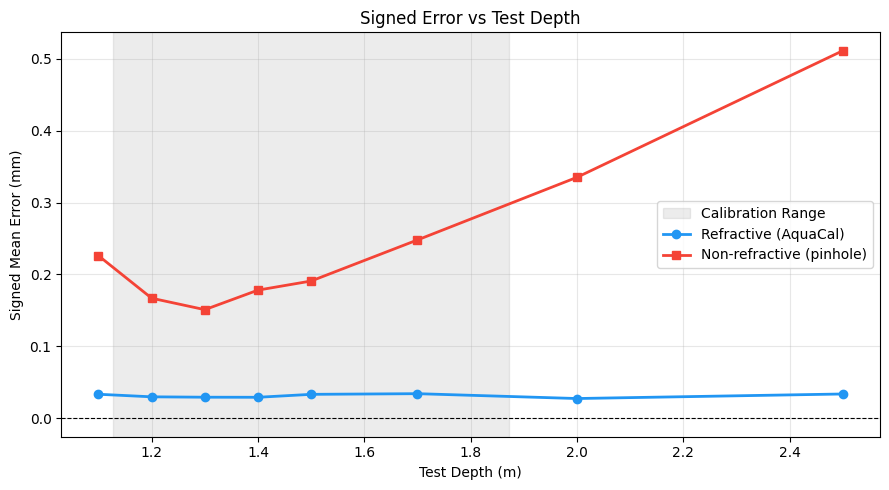

In [11]:
depths_plot = [r["depth"] for r in results_refr_exp2]
signed_refr = [r["signed_mean_mm"] for r in results_refr_exp2]
signed_nonrefr = [r["signed_mean_mm"] for r in results_nonrefr_exp2]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(CALIB_DEPTH_RANGE[0], CALIB_DEPTH_RANGE[1], alpha=0.15, color="gray", label="Calibration Range")
ax.plot(depths_plot, signed_refr, marker="o", color=COLOR_REFRACTIVE, label=LABEL_REFRACTIVE, linewidth=2)
ax.plot(depths_plot, signed_nonrefr, marker="s", color=COLOR_NON_REFRACTIVE, label=LABEL_NON_REFRACTIVE, linewidth=2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Test Depth (m)")
ax.set_ylabel("Signed Mean Error (mm)")
ax.set_title("Signed Error vs Test Depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

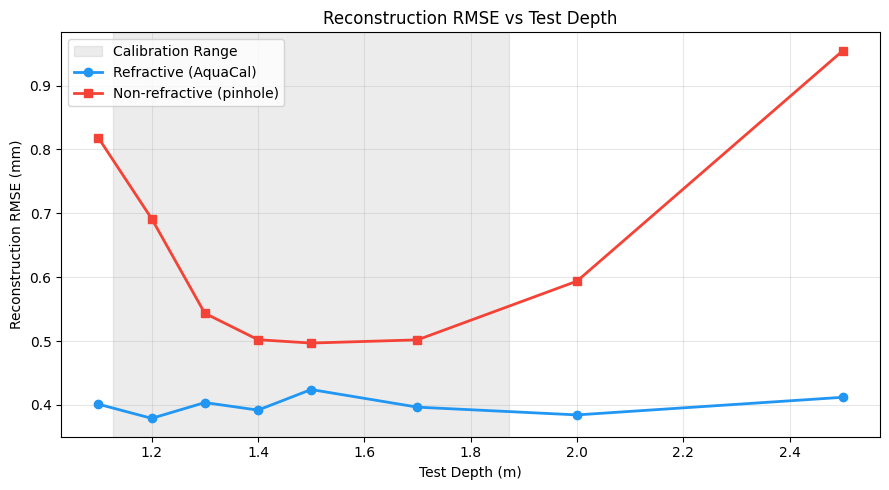

Maximum RMSE across all test depths:
  Refractive:     0.42 mm
  Non-refractive: 0.95 mm


In [12]:
rmse_refr = [r["rmse_mm"] for r in results_refr_exp2]
rmse_nonrefr = [r["rmse_mm"] for r in results_nonrefr_exp2]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(CALIB_DEPTH_RANGE[0], CALIB_DEPTH_RANGE[1], alpha=0.15, color="gray", label="Calibration Range")
ax.plot(depths_plot, rmse_refr, marker="o", color=COLOR_REFRACTIVE, label=LABEL_REFRACTIVE, linewidth=2)
ax.plot(depths_plot, rmse_nonrefr, marker="s", color=COLOR_NON_REFRACTIVE, label=LABEL_NON_REFRACTIVE, linewidth=2)
ax.set_xlabel("Test Depth (m)")
ax.set_ylabel("Reconstruction RMSE (mm)")
ax.set_title("Reconstruction RMSE vs Test Depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

max_rmse_refr = max(rmse_refr)
max_rmse_nonrefr = max(rmse_nonrefr)
print(f"Maximum RMSE across all test depths:")
print(f"  Refractive:     {max_rmse_refr:.2f} mm")
print(f"  Non-refractive: {max_rmse_nonrefr:.2f} mm")

### Reprojection Error vs Depth

Reprojection error measures how well the calibrated model explains the 2D observations
at each test depth using the ground-truth board poses. Unlike 3D reconstruction error,
this is a purely 2D metric — but it still degrades for the non-refractive model
because refraction bends rays by a depth-dependent amount that a fixed pinhole model
cannot accommodate.

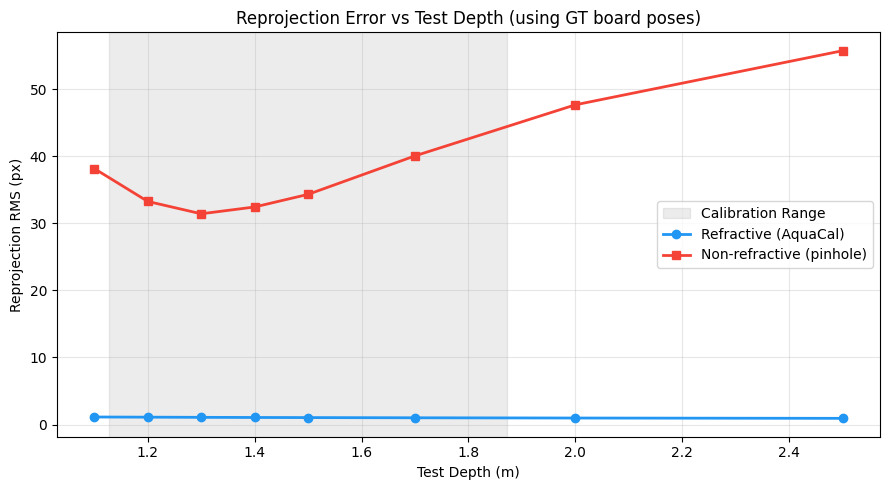

In [13]:
reproj_refr = [r["reproj_rms_px"] for r in results_refr_exp2]
reproj_nonrefr = [r["reproj_rms_px"] for r in results_nonrefr_exp2]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(CALIB_DEPTH_RANGE[0], CALIB_DEPTH_RANGE[1], alpha=0.15, color="gray", label="Calibration Range")
ax.plot(depths_plot, reproj_refr, marker="o", color=COLOR_REFRACTIVE, label=LABEL_REFRACTIVE, linewidth=2)
ax.plot(depths_plot, reproj_nonrefr, marker="s", color=COLOR_NON_REFRACTIVE, label=LABEL_NON_REFRACTIVE, linewidth=2)
ax.set_xlabel("Test Depth (m)")
ax.set_ylabel("Reprojection RMS (px)")
ax.set_title("Reprojection Error vs Test Depth (using GT board poses)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

### Spatial Error Distribution

Are reconstruction errors uniform across the field of view, or concentrated in
certain regions? The heatmaps below show mean signed reconstruction error binned
by XY position for the shallowest and deepest test depths.

The non-refractive model's error is not only larger but spatially structured — it
varies across the field of view because refraction angle depends on the incidence
geometry, which a fixed pinhole distortion model cannot capture.

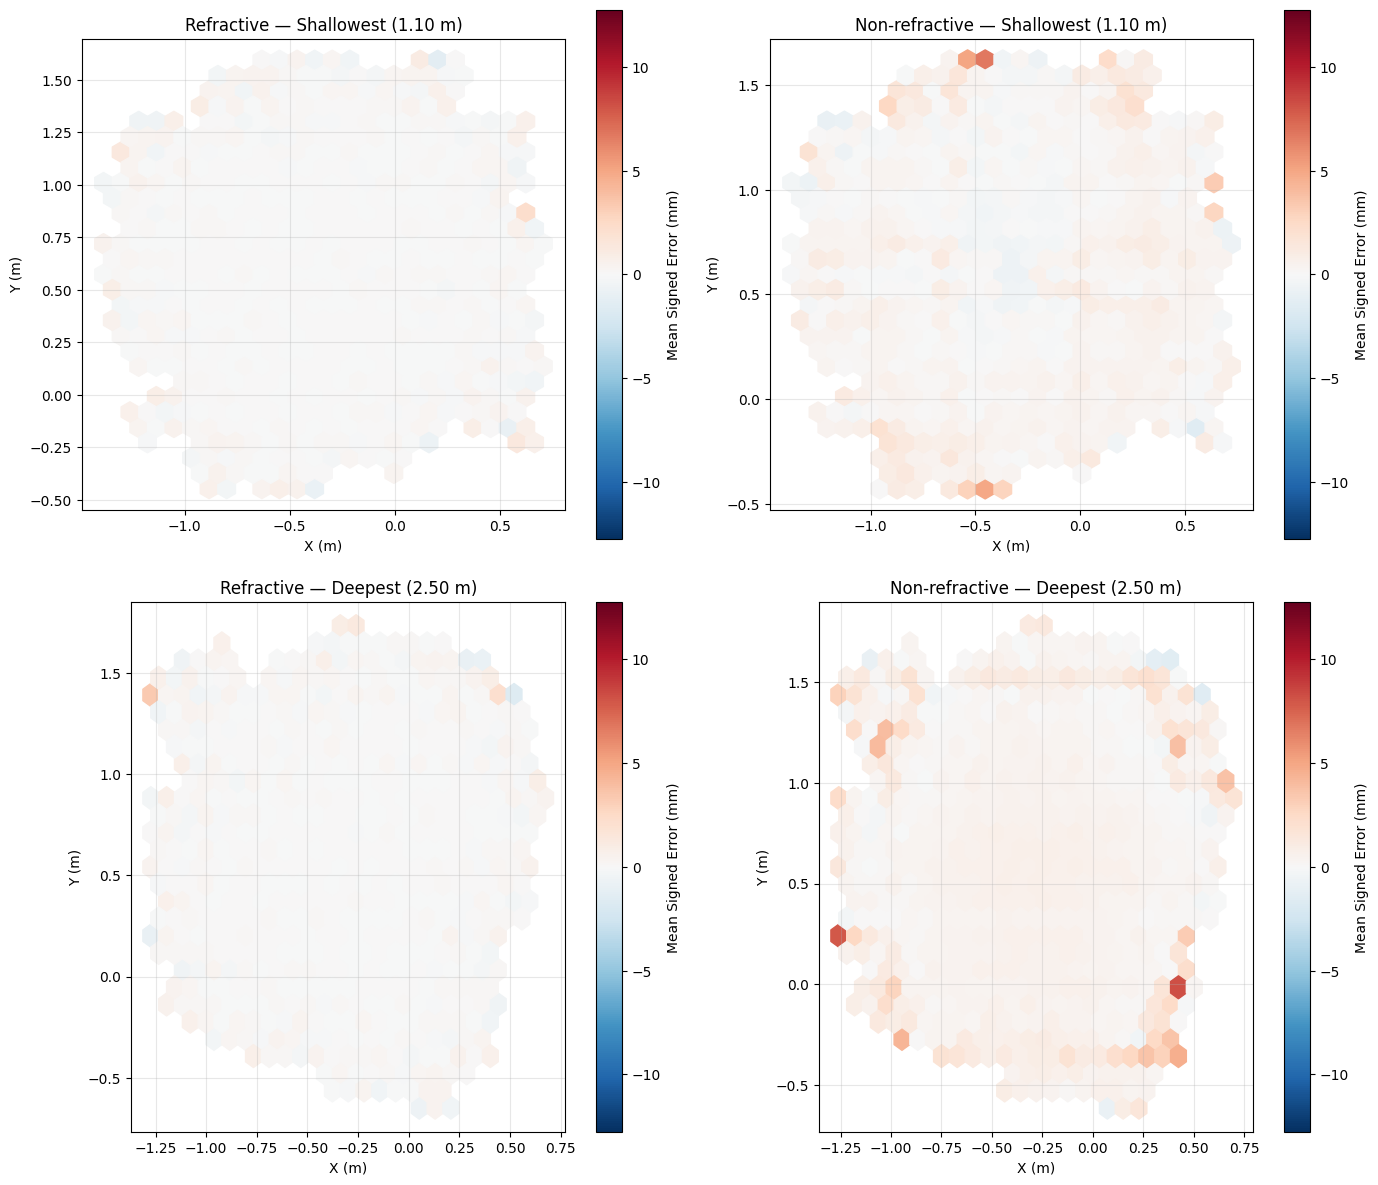

In [14]:
# Pick shallowest and deepest test depths for comparison
depth_indices = [0, len(TEST_DEPTHS) - 1]
depth_labels = ["Shallowest", "Deepest"]

fig, axes = plt.subplots(len(depth_indices), 2, figsize=(14, 6 * len(depth_indices)))

# Compute shared color scale across all panels
all_errors_mm = []
for di in depth_indices:
    for results in [results_refr_exp2, results_nonrefr_exp2]:
        sp = results[di]["spatial"]
        if sp is not None:
            all_errors_mm.extend((sp.signed_errors * 1000).tolist())
if all_errors_mm:
    vmax = max(abs(min(all_errors_mm)), abs(max(all_errors_mm)))
else:
    vmax = 1.0

# Hexbin gridsize: use equal x-y bin widths.  The data spans ~2*XY_EXTENT in
# both X and Y.  A gridsize of 25 gives bins of roughly 40 mm width, which is
# fine enough to show spatial structure without being too noisy.
HEXBIN_GRIDSIZE = 25

for row, (di, dlabel) in enumerate(zip(depth_indices, depth_labels)):
    depth_val = TEST_DEPTHS[di]
    for col, (results, model_label) in enumerate([
        (results_refr_exp2, "Refractive"),
        (results_nonrefr_exp2, "Non-refractive"),
    ]):
        ax = axes[row, col]
        sp = results[di]["spatial"]
        if sp is not None and len(sp.signed_errors) > 0:
            hb = ax.hexbin(
                sp.positions[:, 0], sp.positions[:, 1],
                C=sp.signed_errors * 1000,
                reduce_C_function=np.mean,
                gridsize=HEXBIN_GRIDSIZE,
                cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                mincnt=1,
            )
            plt.colorbar(hb, ax=ax, label="Mean Signed Error (mm)")
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.set_title(f"{model_label} — {dlabel} ({depth_val:.2f} m)")
        ax.set_aspect("equal")
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

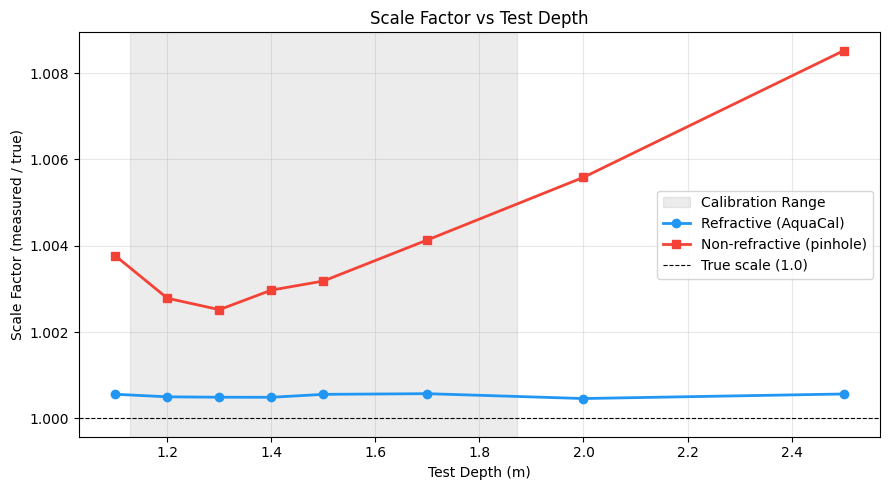

In [15]:
scale_refr = [r["scale"] for r in results_refr_exp2]
scale_nonrefr = [r["scale"] for r in results_nonrefr_exp2]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(CALIB_DEPTH_RANGE[0], CALIB_DEPTH_RANGE[1], alpha=0.15, color="gray", label="Calibration Range")
ax.plot(depths_plot, scale_refr, marker="o", color=COLOR_REFRACTIVE, label=LABEL_REFRACTIVE, linewidth=2)
ax.plot(depths_plot, scale_nonrefr, marker="s", color=COLOR_NON_REFRACTIVE, label=LABEL_NON_REFRACTIVE, linewidth=2)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="True scale (1.0)")
ax.set_xlabel("Test Depth (m)")
ax.set_ylabel("Scale Factor (measured / true)")
ax.set_title("Scale Factor vs Test Depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

### Experiment 2 Takeaway

The refractive model's error stays low and uniform across all test depths — it learned
the actual geometry and produces consistent 3D measurements regardless of depth. The
non-refractive model's error grows with depth because its biased focal lengths and
camera positions produce scale distortions that worsen as targets move further from
the cameras.

This is particularly important for applications where the measurement depth varies:
animal tracking, reef surveys, or any scenario where targets move in depth.

## Experiment 3: XY vs Z Precision Anisotropy

**Question:** Is reconstruction precision uniform in all directions, or does the
camera geometry create a preferred axis?

When all cameras look straight down (optical axes parallel to Z), they have wide
angular separation in XY — each camera views the same target from a different lateral
position. But along Z (depth), all viewing angles are nearly identical. This creates
**anisotropic triangulation geometry**: the system resolves XY position far more
precisely than Z.

This geometric anisotropy affects both models, but the non-refractive model adds
systematic Z bias from its wrong parameters on top. Using the same test data from
Experiment 2, we decompose triangulation error into lateral (XY) and depth (Z)
components to quantify both effects.

In [ ]:
print("=== Experiment 3: XY vs Z Precision Anisotropy ===")
print("Reusing test data from Experiment 2\n")

# For each test depth, triangulate corners and compare to ground truth positions.
# Decompose the 3D position error into XY (lateral) and Z (depth) components.

def compute_xyz_errors(calibration, test_poses, test_detections, board):
    """Triangulate corners, compare to GT, return per-depth XY/Z error arrays."""
    results = []
    poses_by_frame = {bp.frame_idx: bp for bp in test_poses}

    xy_errors = []
    z_errors = []
    signed_z_errors = []

    for frame_idx in test_detections.frames:
        tri_corners = triangulate_charuco_corners(calibration, test_detections, frame_idx)
        if not tri_corners:
            continue

        bp = poses_by_frame[frame_idx]
        R_board, _ = cv2.Rodrigues(bp.rvec)

        for corner_id, tri_pos in tri_corners.items():
            if corner_id not in board.corner_positions:
                continue
            p_board = board.corner_positions[corner_id]
            p_gt = R_board @ p_board + bp.tvec

            err = tri_pos - p_gt
            xy_errors.append(np.linalg.norm(err[:2]))
            z_errors.append(abs(err[2]))
            signed_z_errors.append(err[2])

    xy_arr = np.array(xy_errors)
    z_arr = np.array(z_errors)
    signed_z_arr = np.array(signed_z_errors)
    xy_rmse = np.sqrt(np.mean(xy_arr**2))
    z_rmse = np.sqrt(np.mean(z_arr**2))
    ratio = z_rmse / xy_rmse if xy_rmse > 0 else float("inf")

    return {
        "xy_rmse_mm": xy_rmse * 1000,
        "z_rmse_mm": z_rmse * 1000,
        "xy_mean_signed_mm": np.mean(xy_arr) * 1000,
        "z_mean_signed_mm": np.mean(signed_z_arr) * 1000,
        "ratio": ratio,
        "xy_errors_mm": xy_arr * 1000,
        "z_errors_mm": z_arr * 1000,
        "n_points": len(xy_errors),
    }


exp3_refr = []
exp3_nonrefr = []

for i, depth in enumerate(TEST_DEPTHS):
    test_poses = exp2_test_poses[i]
    test_detections = exp2_test_detections[i]

    r_refr = compute_xyz_errors(result_refr, test_poses, test_detections, board_exp2)
    r_nonrefr = compute_xyz_errors(result_nonrefr, test_poses, test_detections, board_exp2)
    r_refr["depth"] = depth
    r_nonrefr["depth"] = depth
    exp3_refr.append(r_refr)
    exp3_nonrefr.append(r_nonrefr)

    print(f"  Z = {depth:.2f} m:")
    print(f"    Refractive:     XY = {r_refr['xy_rmse_mm']:.3f} mm, "
          f"Z = {r_refr['z_rmse_mm']:.3f} mm, ratio = {r_refr['ratio']:.1f}x")
    print(f"    Non-refractive: XY = {r_nonrefr['xy_rmse_mm']:.3f} mm, "
          f"Z = {r_nonrefr['z_rmse_mm']:.3f} mm, ratio = {r_nonrefr['ratio']:.1f}x")

print("\nAnisotropy analysis complete.")

### XY vs Z RMSE across Depth

The grouped bar chart below compares lateral (XY) and depth (Z) reconstruction RMSE
for both models at each test depth. The refractive model shows the baseline geometric
anisotropy; the non-refractive model amplifies it with systematic Z bias from its
wrong parameters.

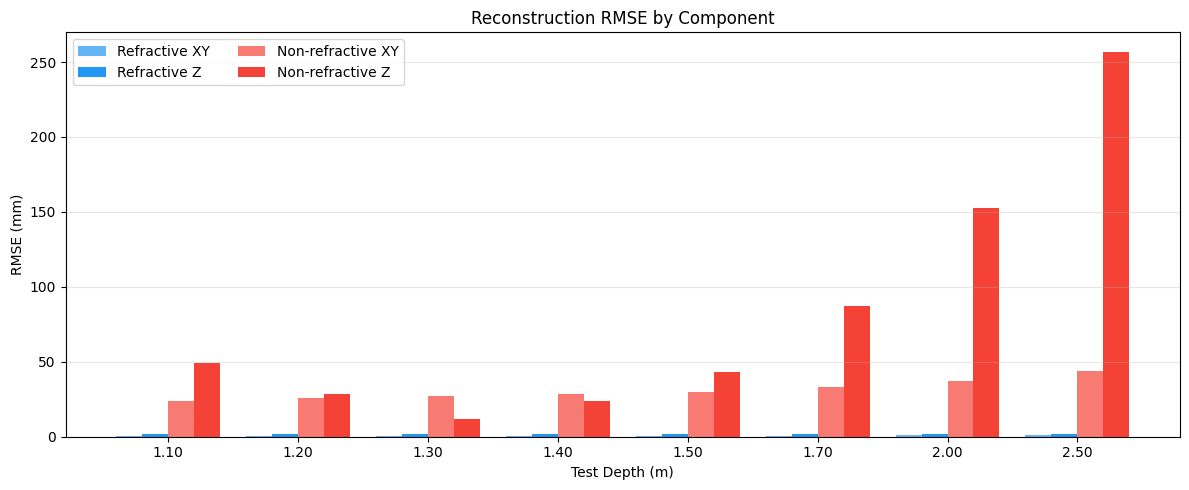

In [17]:
depths_exp3 = [r["depth"] for r in exp3_refr]
x_pos = np.arange(len(depths_exp3))
w = 0.2  # bar width

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - 1.5 * w, [r["xy_rmse_mm"] for r in exp3_refr], w,
       label="Refractive XY", color=COLOR_REFRACTIVE, alpha=0.7)
ax.bar(x_pos - 0.5 * w, [r["z_rmse_mm"] for r in exp3_refr], w,
       label="Refractive Z", color=COLOR_REFRACTIVE)
ax.bar(x_pos + 0.5 * w, [r["xy_rmse_mm"] for r in exp3_nonrefr], w,
       label="Non-refractive XY", color=COLOR_NON_REFRACTIVE, alpha=0.7)
ax.bar(x_pos + 1.5 * w, [r["z_rmse_mm"] for r in exp3_nonrefr], w,
       label="Non-refractive Z", color=COLOR_NON_REFRACTIVE)
ax.set_xlabel("Test Depth (m)")
ax.set_ylabel("RMSE (mm)")
ax.set_title("Reconstruction RMSE by Component")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{d:.2f}" for d in depths_exp3])
ax.legend(ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

### Anisotropy Ratio vs Depth

The ratio Z_RMSE / XY_RMSE quantifies how many times worse depth precision is
compared to lateral precision. A ratio of 1 would indicate isotropic precision;
higher values indicate a "cigar-shaped" error distribution elongated along Z.

Both models show anisotropy from the rig geometry, but the non-refractive model's
ratio is higher because its systematic Z bias adds to the geometric limitation.

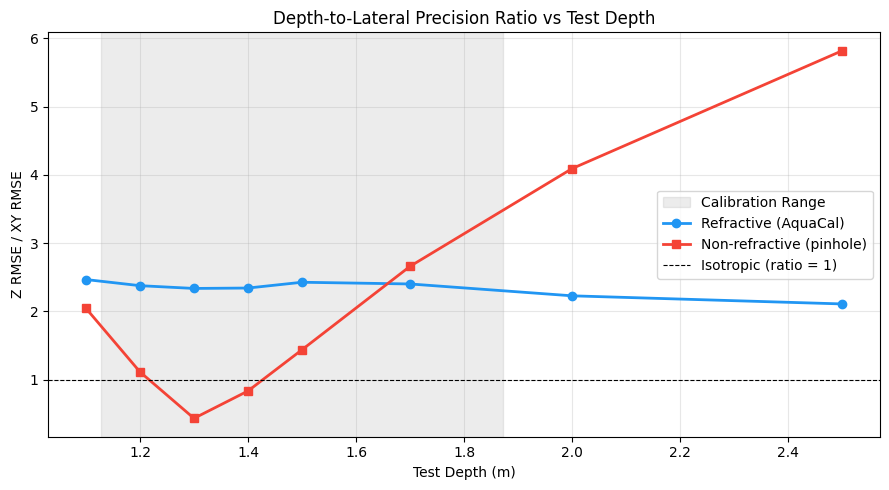

Anisotropy ratio (refractive):     2.1x – 2.5x (mean 2.3x)
Anisotropy ratio (non-refractive): 0.4x – 5.8x (mean 2.3x)


In [18]:
ratios_refr = [r["ratio"] for r in exp3_refr]
ratios_nonrefr = [r["ratio"] for r in exp3_nonrefr]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(CALIB_DEPTH_RANGE[0], CALIB_DEPTH_RANGE[1], alpha=0.15, color="gray", label="Calibration Range")
ax.plot(depths_exp3, ratios_refr, marker="o", color=COLOR_REFRACTIVE,
        label=LABEL_REFRACTIVE, linewidth=2)
ax.plot(depths_exp3, ratios_nonrefr, marker="s", color=COLOR_NON_REFRACTIVE,
        label=LABEL_NON_REFRACTIVE, linewidth=2)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="Isotropic (ratio = 1)")
ax.set_xlabel("Test Depth (m)")
ax.set_ylabel("Z RMSE / XY RMSE")
ax.set_title("Depth-to-Lateral Precision Ratio vs Test Depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

print(f"Anisotropy ratio (refractive):     {min(ratios_refr):.1f}x – {max(ratios_refr):.1f}x "
      f"(mean {np.mean(ratios_refr):.1f}x)")
print(f"Anisotropy ratio (non-refractive): {min(ratios_nonrefr):.1f}x – {max(ratios_nonrefr):.1f}x "
      f"(mean {np.mean(ratios_nonrefr):.1f}x)")

### Error Distribution: Shallowest vs Deepest

Violin plots show the full distribution of per-point errors at the shallowest
and deepest test depths for both models. The non-refractive model's Z distribution
is dramatically wider — its systematic bias stacks on top of the geometric
anisotropy that both models share.

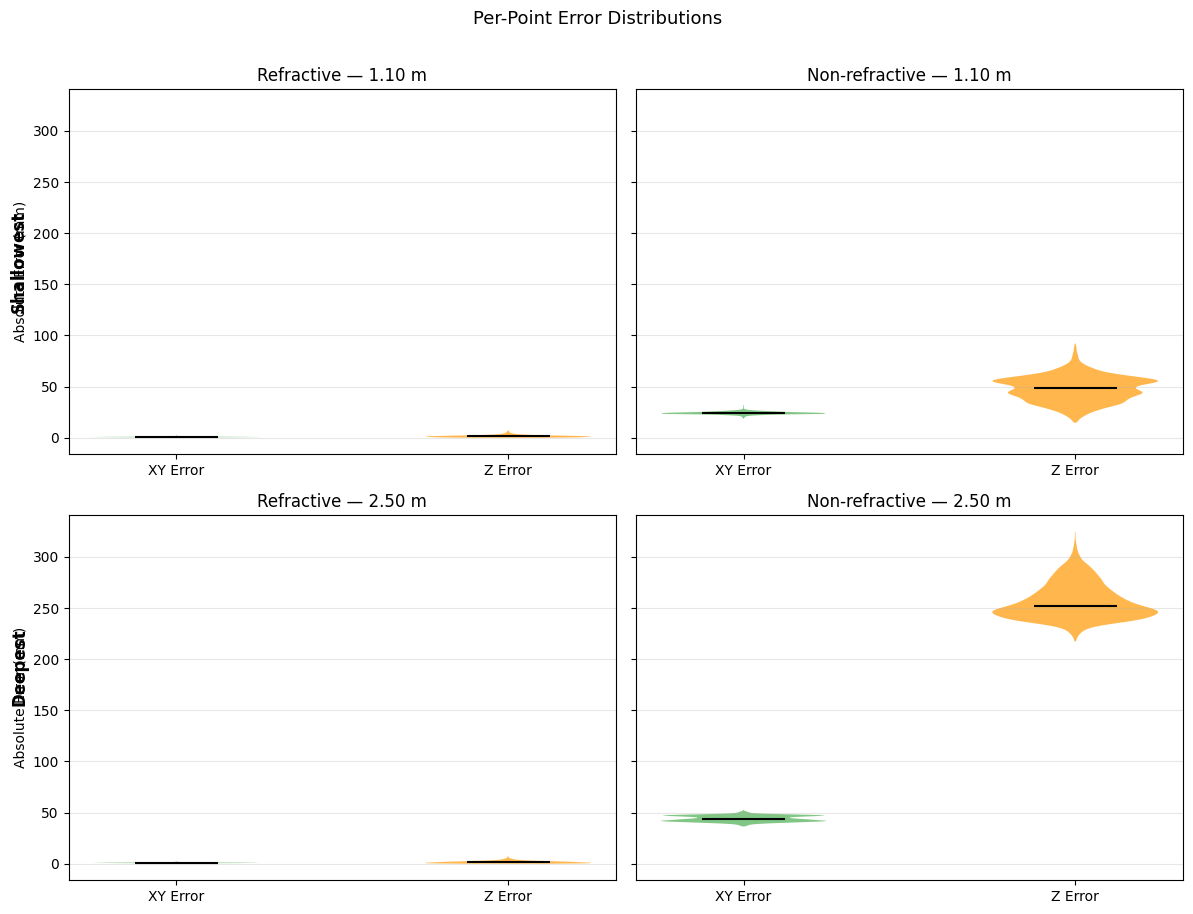

Shallowest (1.10 m):
  Refractive     — XY median: 0.667 mm, Z median: 1.293 mm
  Non-refractive — XY median: 24.034 mm, Z median: 48.312 mm
Deepest (2.50 m):
  Refractive     — XY median: 0.849 mm, Z median: 1.341 mm
  Non-refractive — XY median: 43.759 mm, Z median: 252.402 mm


In [19]:
# 2x2 grid: rows = shallowest/deepest, cols = refractive/non-refractive
shallow_refr, deep_refr = exp3_refr[0], exp3_refr[-1]
shallow_nonrefr, deep_nonrefr = exp3_nonrefr[0], exp3_nonrefr[-1]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)

panels = [
    (axes[0, 0], shallow_refr, f"Refractive — {shallow_refr['depth']:.2f} m"),
    (axes[0, 1], shallow_nonrefr, f"Non-refractive — {shallow_nonrefr['depth']:.2f} m"),
    (axes[1, 0], deep_refr, f"Refractive — {deep_refr['depth']:.2f} m"),
    (axes[1, 1], deep_nonrefr, f"Non-refractive — {deep_nonrefr['depth']:.2f} m"),
]

for ax, result, label in panels:
    data = [result["xy_errors_mm"], result["z_errors_mm"]]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True, showextrema=False)

    for pc, color in zip(parts["bodies"], ["#4CAF50", "#FF9800"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("black")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["XY Error", "Z Error"])
    ax.set_title(label)
    ax.grid(axis="y", alpha=0.3)

axes[0, 0].set_ylabel("Absolute Error (mm)")
axes[1, 0].set_ylabel("Absolute Error (mm)")
fig.text(0.01, 0.73, "Shallowest", va="center", rotation="vertical", fontsize=12, fontweight="bold")
fig.text(0.01, 0.28, "Deepest", va="center", rotation="vertical", fontsize=12, fontweight="bold")
fig.suptitle("Per-Point Error Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
plt.close()

print(f"Shallowest ({shallow_refr['depth']:.2f} m):")
print(f"  Refractive     — XY median: {np.median(shallow_refr['xy_errors_mm']):.3f} mm, "
      f"Z median: {np.median(shallow_refr['z_errors_mm']):.3f} mm")
print(f"  Non-refractive — XY median: {np.median(shallow_nonrefr['xy_errors_mm']):.3f} mm, "
      f"Z median: {np.median(shallow_nonrefr['z_errors_mm']):.3f} mm")
print(f"Deepest ({deep_refr['depth']:.2f} m):")
print(f"  Refractive     — XY median: {np.median(deep_refr['xy_errors_mm']):.3f} mm, "
      f"Z median: {np.median(deep_refr['z_errors_mm']):.3f} mm")
print(f"  Non-refractive — XY median: {np.median(deep_nonrefr['xy_errors_mm']):.3f} mm, "
      f"Z median: {np.median(deep_nonrefr['z_errors_mm']):.3f} mm")

### Experiment 3 Takeaway

Reconstruction precision is highly anisotropic: Z (depth) errors are consistently
larger than XY (lateral) errors for both models. The refractive model shows the
**baseline geometric anisotropy** — an inherent consequence of the downward-looking
camera arrangement where all cameras share a similar viewing angle along Z. The
non-refractive model makes it worse: its systematic parameter bias amplifies Z
error while leaving XY relatively unchanged, producing even higher anisotropy ratios.

**Practical implications:**
- **XY tracking** (e.g. horizontal position of fish) is inherently precise with
  either model
- **Depth estimation** (Z) is the limiting factor — and the non-refractive model
  makes it substantially worse
- Applications that only need 2D plan-view tracking can expect significantly
  better precision than the overall 3D RMSE suggests
- For depth-critical applications, use the refractive model *and* consider adding
  cameras at oblique angles to improve Z triangulation geometry

### Exported Data

The CSVs below capture the per-record data behind all plots in this notebook,
so downstream consumers can reproduce statistics and figures without running AquaCal.

## Summary

Three experiments, one calibration:

| Experiment | What we tested | Key finding |
|------------|---------------|-------------|
| 1 — Parameter Fidelity | Same data, two models | Non-refractive absorbs refraction into focal length and position bias |
| 2 — Depth Generalization | Same calibration, sweep test depth | Non-refractive error grows with depth; refractive stays flat |
| 3 — XY vs Z Anisotropy | Decompose error by direction | Z error dominates XY for both models; non-refractive amplifies the gap |

**When is refractive calibration essential?**
- Camera-to-water distance is significant (>= 0.3 m)
- Measurement depth varies across sessions or within a session
- High 3D accuracy is required (< 5 mm)
- You need stable calibration across depth ranges

**When might pinhole be acceptable?**
- Cameras are very close to the water surface (< 0.1 m)
- Only 2D detection or tracking is needed (no 3D reconstruction)
- Accuracy requirements are very relaxed (> 20 mm)
- Data collection depth is constant and pre-known

---

**Further reading:**
- [Full pipeline tutorial](01_full_pipeline.ipynb) — calibrate a rig end-to-end
- [Theory documentation](../guide/refractive_geometry.md) — refractive geometry model and Snell's law derivation
- [Optimizer guide](../guide/optimizer.md) — tuning the Stage 3 bundle adjustment